# LendingClub Credit Scorecard — Build & Out-of-Time Validation

Builds a traditional WOE/logistic-regression credit scorecard for predicting loan
default, using only applicant/bureau features available **at origination**
(LendingClub's own `grade`, `sub_grade`, `int_rate`, `installment` are excluded —
those are LC's own risk decision and would leak the answer into the model).

**FICO is included, but not as a raw score — as a rolling percentile rank.**

FICO (and bureau scores generally) get revamped periodically (e.g. FICO 8 → 9 →
10), which can silently shift what a given score value means and stale-date a
scorecard's fixed bin edges without any real change in borrower risk. LendingClub's
data has no field flagging which score version was used or when it changed, so
there's no way to detect a revamp directly from the data — the mitigation has to
be structural instead.

The fix used here: each loan's FICO is converted to its **percentile rank against
a trailing 6-month reference window of originations** (`fico_percentile`), and the
scorecard is built on that percentile rather than the raw score. Score revamps
typically preserve the *relative ordering* of borrowers even when they shift the
absolute point scale, so a percentile rank stays meaningful across a version change
in a way a fixed bin like `(-inf, 667.0]` does not.

Trade-off, for the record: this requires maintaining a live rolling reference
distribution at scoring time (more operational overhead than a static lookup
table), and because the percentile is always relative to a moving population, it
would *mask* a genuine population-wide credit-quality shift (everyone getting
riskier shows up as a re-centering, not a score change) — so the raw score's
trend/PSI should still be monitored separately as a signal, even though it's not
a model input.

**Validation design:** out-of-time split. Loans issued **2007–2015** train the
model; loans issued in **2016** are held out for testing. 2017–2018 vintages are
excluded entirely — the EDA showed their resolved-loan mix is skewed by
right-censoring (many loans haven't had time to default or fully pay off yet),
which would bias any out-of-sample read on those vintages.

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load & prepare data

Only applicant/bureau columns are loaded — no `grade`, `sub_grade`, `int_rate`, or `installment` (LC's own risk decision). FICO is loaded but only to build the rolling-percentile feature below, never as a raw score.

In [2]:
usecols = [
    "loan_amnt", "term", "emp_length", "home_ownership", "annual_inc",
    "verification_status", "issue_d", "loan_status", "purpose", "dti",
    "delinq_2yrs", "inq_last_6mths", "fico_range_low", "fico_range_high",
    "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "mort_acc", "pub_rec_bankruptcies",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 21)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
print(f"Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")

Train (issued < 2016): 826,606 loans, default rate 18.43%
Test  (issued 2016)  : 293,105 loans, default rate 23.29%


## 2. FICO as a rolling-percentile feature

For each loan, `fico_percentile` is its FICO rank (0-1) against a **trailing
6-month window of originations that ends before its own issue month** — never
using loans from its own month or later, so this is causally valid (a real scoring
system would only ever have trailing history to compare against too).

This is computed once, up front, over the full dataset (`df`), purely from FICO
values with no reference to `is_default` — so there's no target leakage, and it's
independent of the later train/test split.

In [4]:
K_MONTHS = 6  # trailing window for the FICO reference population

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        # only the very first origination month in the whole dataset has no trailing
        # history; fall back to its own distribution rather than leaving it undefined.
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

# re-attach to train/test (built from df before this feature existed)
train["fico_percentile"] = df.loc[train.index, "fico_percentile"]
test["fico_percentile"] = df.loc[test.index, "fico_percentile"]

print(train["fico_percentile"].describe())
print(test["fico_percentile"].describe())

count    826606.000000
mean          0.464601
std           0.302210
min           0.000000
25%           0.195645
50%           0.458208
75%           0.723260
max           1.000000
Name: fico_percentile, dtype: float64
count    293105.000000
mean          0.468605
std           0.303542
min           0.000000
25%           0.186141
50%           0.485335
75%           0.727584
max           0.999881
Name: fico_percentile, dtype: float64


## 3. WOE binning

Bin edges / category groupings are derived **only from the training set**, then applied unchanged to the test set — this is what makes the out-of-sample test valid (no leakage of test-set distribution into the binning).

In [5]:
NUMERIC_FEATURES = [
    "loan_amnt", "annual_inc", "dti", "delinq_2yrs", "fico_percentile",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "pub_rec_bankruptcies", "emp_length_years",
]
CATEGORICAL_FEATURES = ["home_ownership", "verification_status", "purpose", "term_months"]

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5  # additive smoothing for WOE on small bins


def fit_numeric_bins(series, n_bins=10):
    """Return sorted unique quantile edges (train-derived), -inf/+inf capped."""
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    keep = set(freq[freq >= min_share].index)
    return keep


def apply_categorical_groups(series, keep):
    out = series.where(series.isin(keep), RARE_LABEL)
    return out.fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good = grp["good"].sum()
    total_bad = grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


bin_edges = {}
cat_groups = {}
woe_tables = {}
iv_summary = {}

for feat in NUMERIC_FEATURES:
    edges = fit_numeric_bins(train[feat])
    bin_edges[feat] = edges
    binned_train = apply_numeric_bins(train[feat], edges)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

for feat in CATEGORICAL_FEATURES:
    keep = fit_categorical_groups(train[feat])
    cat_groups[feat] = keep
    binned_train = apply_categorical_groups(train[feat], keep)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
iv_series

term_months             0.240284
fico_percentile         0.109975
dti                     0.074887
verification_status     0.051283
loan_amnt               0.036846
annual_inc              0.031302
mort_acc                0.027201
revol_util              0.022246
home_ownership          0.020853
purpose                 0.019845
inq_last_6mths          0.018251
open_acc                0.007920
emp_length_years        0.006477
revol_bal               0.003456
delinq_2yrs             0.001353
pub_rec                 0.000983
pub_rec_bankruptcies    0.000692
total_acc               0.000367
dtype: float64

### Information Value reference

| IV range | Predictive power |
|---|---|
| < 0.02 | Not useful |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Suspiciously strong (check for leakage) |

In [6]:
SELECTED_FEATURES = iv_series[iv_series >= 0.02].index.tolist()
print(f"Selected {len(SELECTED_FEATURES)} of {len(iv_series)} features (IV >= 0.02):")
print(SELECTED_FEATURES)

Selected 9 of 18 features (IV >= 0.02):
['term_months', 'fico_percentile', 'dti', 'verification_status', 'loan_amnt', 'annual_inc', 'mort_acc', 'revol_util', 'home_ownership']


## 4. Check WOE monotonicity for top features

A well-behaved scorecard variable has WOE that moves monotonically (or with a clear, explainable U-shape) across ordered bins.

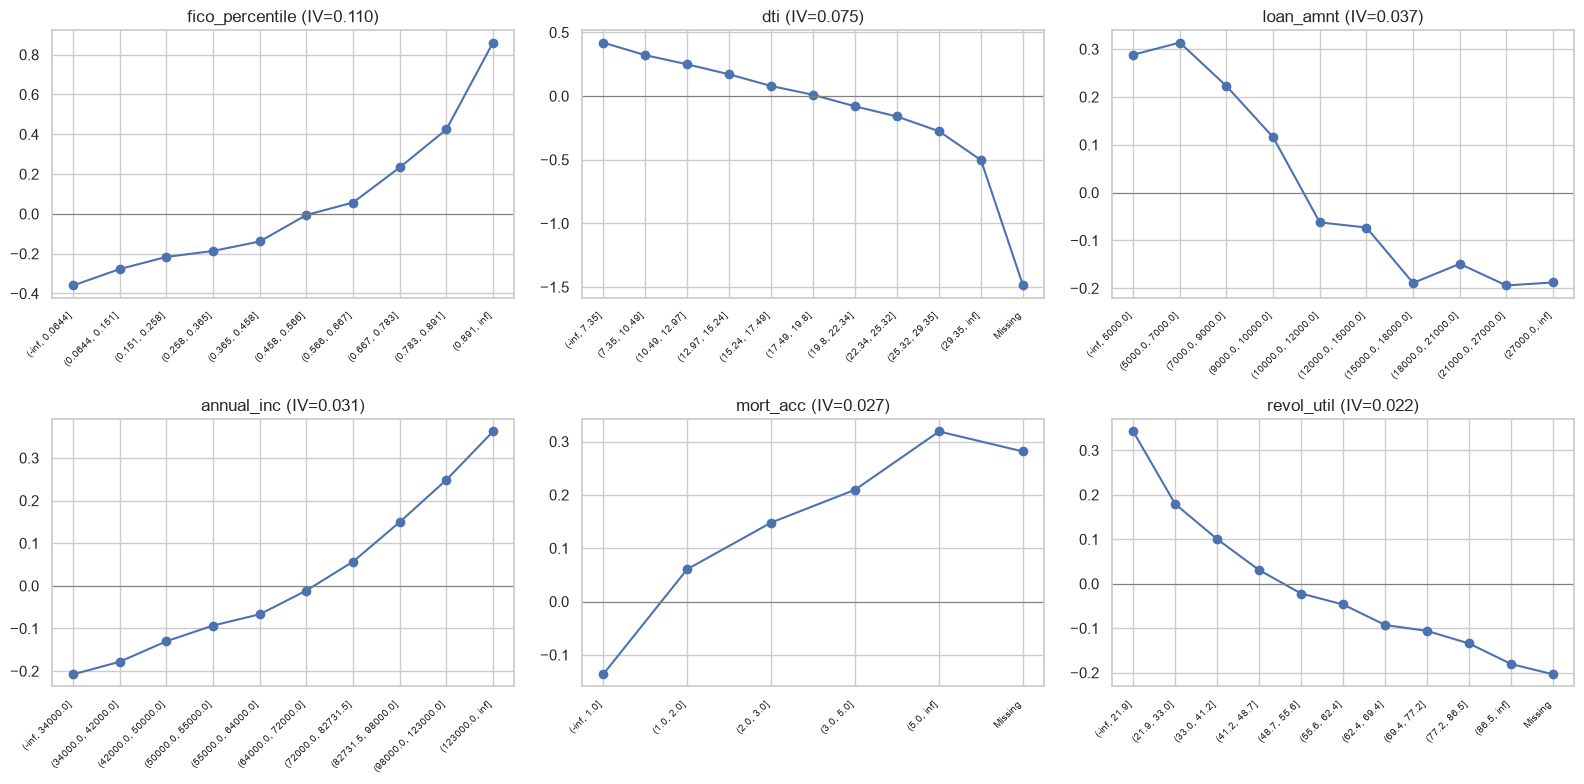

In [7]:
def sort_bins(tab):
    """Sort interval bins by their left edge, pushing the Missing bin to the end."""
    def sort_key(bin_label):
        if isinstance(bin_label, pd.Interval):
            return (0, bin_label.left)
        return (1, 0)
    order = sorted(tab.index, key=sort_key)
    return tab.loc[order]


top_numeric = [f for f in SELECTED_FEATURES if f in NUMERIC_FEATURES][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, top_numeric):
    tab = sort_bins(woe_tables[feat])
    ax.plot(range(len(tab)), tab["woe"], marker="o")
    ax.set_xticks(range(len(tab)))
    ax.set_xticklabels([str(i) for i in tab.index], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{feat} (IV={iv_summary[feat]:.3f})")
    ax.axhline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Transform train & test to WOE features

In [8]:
def transform_to_woe(data, features):
    out = pd.DataFrame(index=data.index)
    for feat in features:
        woe_tab = woe_tables[feat]
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        mapped = binned.map(woe_tab["woe"])
        # bin present in test but not seen in train (e.g. novel category) -> WOE 0 (neutral)
        out[feat] = mapped.fillna(0.0)
    return out

X_train = transform_to_woe(train, SELECTED_FEATURES)
X_test = transform_to_woe(test, SELECTED_FEATURES)
y_train = train["is_default"].values
y_test = test["is_default"].values

X_train.shape, X_test.shape

((826606, 9), (293105, 9))

## 6. Fit logistic regression on WOE features

In [9]:
model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_[0], index=SELECTED_FEATURES).sort_values()
print("Intercept:", model.intercept_[0])
coef_table

Intercept: -1.4883106983822099


fico_percentile       -0.999069
term_months           -0.982830
annual_inc            -0.832081
home_ownership        -0.731839
dti                   -0.679933
mort_acc              -0.655517
verification_status   -0.426816
loan_amnt             -0.424396
revol_util             0.356672
dtype: float64

Every WOE coefficient should be **negative**: a higher WOE means more good (safe) borrowers in that bin, so it should push the predicted probability of default *down*. A positive coefficient signals a badly-behaved variable.

In [10]:
bad_sign = coef_table[coef_table > 0]
if len(bad_sign):
    print("WARNING - unexpected positive coefficients:", bad_sign.index.tolist())
else:
    print("All coefficients have the expected negative sign.")

WARNING - unexpected positive coefficients: ['revol_util']


## 7. Out-of-sample performance: AUC, Gini, KS

In [11]:
def ks_statistic(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.array(y_true)[order]
    cum_bad = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    cum_good = np.cumsum(1 - y_true_sorted) / (1 - y_true_sorted).sum()
    return np.max(np.abs(cum_bad - cum_good))


def report_performance(y_true, proba, label):
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, proba)
    print(f"{label:>12}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    return auc, gini, ks

train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

train_perf = report_performance(y_train, train_proba, "Train (IS)")
test_perf = report_performance(y_test, test_proba, "Test (OOS)")

  Train (IS): AUC=0.6892  Gini=0.3785  KS=0.2712
  Test (OOS): AUC=0.6763  Gini=0.3527  KS=0.2489


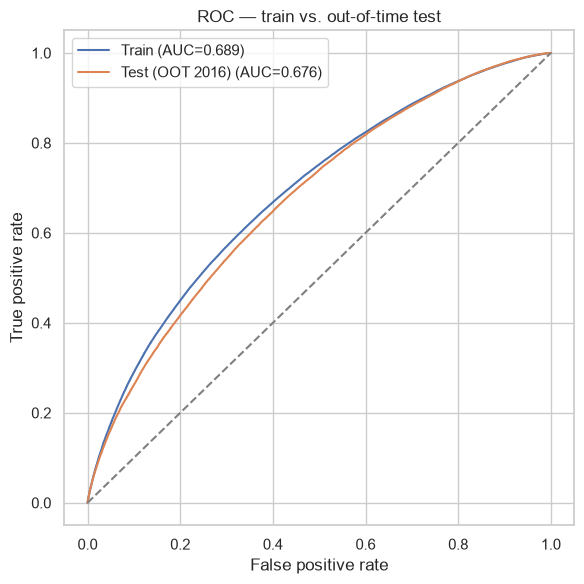

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
for y_true, proba, label in [(y_train, train_proba, "Train"), (y_test, test_proba, "Test (OOT 2016)")]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC — train vs. out-of-time test")
ax.legend()
plt.tight_layout()
plt.show()

A modest gap between train and test AUC/KS is expected and healthy (some overfitting to train, and 2016 is a genuinely different time period). A *large* gap would suggest overfitting or instability; near-identical or better OOS performance would be suspicious.

## 8. Convert to a points-based scorecard

Standard scaling: choose a base score and base odds, plus points-to-double-odds (PDO), then distribute the logistic regression's log-odds contribution across bins as points.

In [13]:
BASE_SCORE = 600
BASE_ODDS = 50   # odds of good:bad at the base score
PDO = 20         # points to double the odds

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

n_features = len(SELECTED_FEATURES)
base_points = offset + factor * model.intercept_[0]

scorecard_rows = []
for feat, coef in zip(SELECTED_FEATURES, model.coef_[0]):
    tab = woe_tables[feat]
    for bin_label, row in tab.iterrows():
        points = -(coef * row["woe"] + model.intercept_[0] / n_features) * factor + offset / n_features
        scorecard_rows.append({
            "feature": feat,
            "bin": bin_label,
            "n_train": int(row["n"]),
            "bad_rate_train": row["bad"] / row["n"],
            "woe": row["woe"],
            "points": round(points, 1),
        })

scorecard = pd.DataFrame(scorecard_rows)
scorecard.head(20)

,feature,bin,n_train,bad_rate_train,woe,points
0,term_months,36.0,618584,0.138954,0.336202,68.4
1,term_months,60.0,208022,0.318952,-0.729206,38.2
2,fico_percentile,"(-inf, 0.0644]",82932,0.244489,-0.359569,48.5
3,fico_percentile,"(0.0644, 0.151]",82581,0.229581,-0.277112,50.9
4,fico_percentile,"(0.151, 0.258]",82531,0.218960,-0.216058,52.7
5,fico_percentile,"(0.258, 0.365]",85384,0.213904,-0.186244,53.5
6,fico_percentile,"(0.365, 0.458]",80895,0.205995,-0.138561,54.9
7,fico_percentile,"(0.458, 0.566]",82606,0.185071,-0.005440,58.7
8,fico_percentile,"(0.566, 0.667]",82046,0.175816,0.057154,60.5
9,fico_percentile,"(0.667, 0.783]",82706,0.151742,0.233194,65.6


In [14]:
# Vectorized scoring using the fitted WOE features directly (equivalent to summing scorecard points)
def compute_scores(X_woe):
    # model predicts P(is_default=1) i.e. "bad", so its raw log-odds are log-odds of BAD.
    # A credit score should rise with safety, so we negate to get log-odds of good.
    log_odds_bad = model.intercept_[0] + X_woe.values @ model.coef_[0]
    log_odds_good = -log_odds_bad
    return offset + factor * log_odds_good

train_scores = compute_scores(X_train)
test_scores = compute_scores(X_test)

train["score"] = train_scores
test["score"] = test_scores

print(train["score"].describe())
print(test["score"].describe())

count    826606.000000
mean        534.394366
std          20.550621
min         472.101784
25%         521.828235
50%         535.397833
75%         547.826476
max         600.033715
Name: score, dtype: float64
count    293105.000000
mean        535.044345
std          19.723752
min         463.142154
25%         523.355787
50%         535.326040
75%         547.609398
max         596.711408
Name: score, dtype: float64


In [15]:
# Sanity check: summing each loan's per-bin scorecard points should reproduce compute_scores()
# exactly. This catches sign/scaling bugs between the "points table" and the scoring function.
def points_lookup(data, features):
    total = pd.Series(0.0, index=data.index)
    for feat in features:
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        points_map = scorecard[scorecard["feature"] == feat].set_index("bin")["points"]
        total = total + binned.map(points_map).fillna(0.0)
    return total

sample_idx = train.sample(2000, random_state=0).index
points_check = points_lookup(train.loc[sample_idx], SELECTED_FEATURES)
score_check = pd.Series(compute_scores(X_train.loc[sample_idx]), index=sample_idx)
max_diff = (points_check - score_check).abs().max()
print(f"Max |points-table score - compute_scores()| over sample: {max_diff:.4f}")
assert max_diff < 1.0, "Points table and compute_scores() disagree — sign/scaling bug."

Max |points-table score - compute_scores()| over sample: 0.2422


Also, a higher score must correspond to a **lower** observed bad rate. Checking this on the training data before trusting the out-of-time results below.

In [16]:
train_score_check = pd.qcut(train["score"], 5, duplicates="drop")
direction_check = train.groupby(train_score_check, observed=True)["is_default"].mean()
print(direction_check)
assert direction_check.iloc[0] > direction_check.iloc[-1], "Score is inverted: lowest band should have the highest default rate."
print("Score direction confirmed: higher score -> lower default rate.")

score
(472.101, 517.545]    0.358016
(517.545, 530.706]    0.214060
(530.706, 539.998]    0.159544
(539.998, 551.055]    0.120069
(551.055, 600.034]    0.069568
Name: is_default, dtype: float64
Score direction confirmed: higher score -> lower default rate.


## 9. Score distribution & calibration on the out-of-time test set

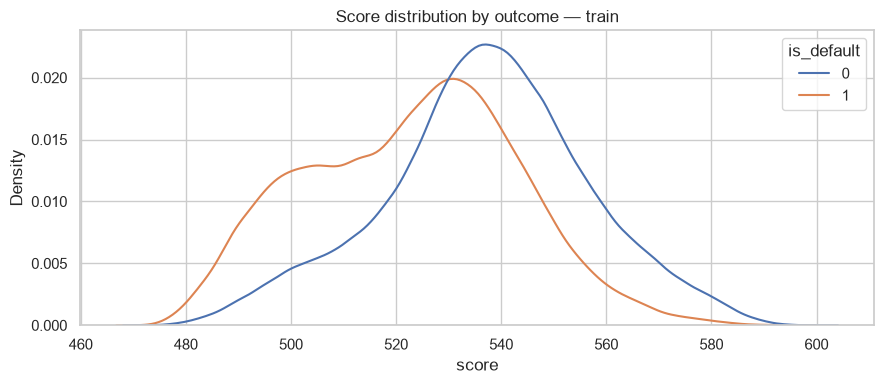

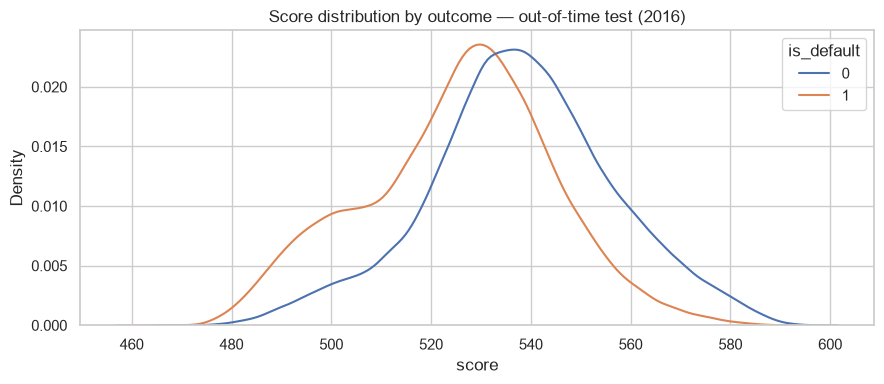

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=train, x="score", hue="is_default", common_norm=False, ax=ax)
ax.set_title("Score distribution by outcome — train")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=test, x="score", hue="is_default", common_norm=False, ax=ax)
ax.set_title("Score distribution by outcome — out-of-time test (2016)")
plt.tight_layout()
plt.show()

In [18]:
test["score_band"] = pd.qcut(test["score"], 10, duplicates="drop")
calibration = test.groupby("score_band", observed=True).agg(
    n=("is_default", "size"),
    actual_default_rate=("is_default", "mean"),
    avg_score=("score", "mean"),
).sort_values("avg_score", ascending=False)
calibration

,n,actual_default_rate,avg_score
score_band,,,
"(560.311, 596.711]",29311,0.069121,569.532449
"(550.898, 560.311]",29310,0.120607,555.181170
"(544.752, 550.898]",29311,0.149398,547.684351
"(539.81, 544.752]",29310,0.179086,542.224607
"(535.326, 539.81]",29310,0.204708,537.558192
"(530.956, 535.326]",29311,0.232745,533.143131
"(526.202, 530.956]",29310,0.262231,528.656777
"(519.927, 526.202]",29311,0.291597,523.275248
"(508.686, 519.927]",29310,0.343876,514.985836


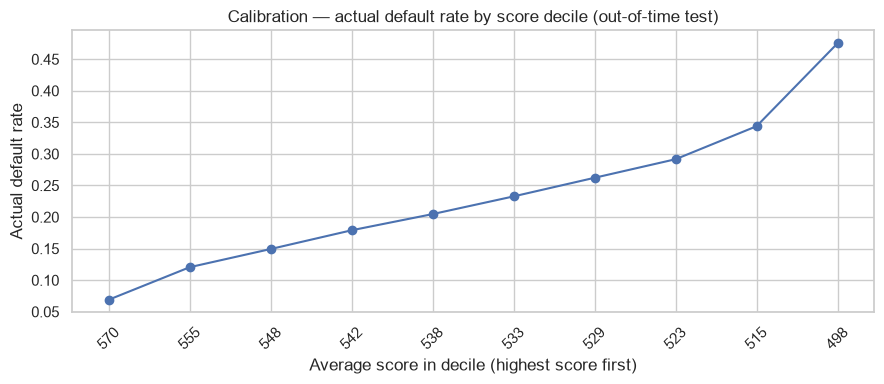

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(calibration)), calibration["actual_default_rate"], marker="o")
ax.set_xticks(range(len(calibration)))
ax.set_xticklabels([f"{v:.0f}" for v in calibration["avg_score"]], rotation=45)
ax.set_xlabel("Average score in decile (highest score first)")
ax.set_ylabel("Actual default rate")
ax.set_title("Calibration — actual default rate by score decile (out-of-time test)")
plt.tight_layout()
plt.show()

A well-calibrated, discriminating scorecard shows actual default rate falling
steadily as score rises (moving left to right through deciles from highest to
lowest score) with no reversals.

## 10. Population Stability Index (PSI): train vs. out-of-time test score distributions

PSI checks whether the *population* being scored has drifted between build and test periods — a separate question from accuracy. PSI < 0.1 is stable, 0.1–0.25 is a moderate shift worth monitoring, > 0.25 signals the population has changed materially.

In [20]:
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    edges = np.unique(edges)
    e_counts = np.histogram(expected, bins=edges)[0] / len(expected)
    a_counts = np.histogram(actual, bins=edges)[0] / len(actual)
    e_counts = np.where(e_counts == 0, 1e-6, e_counts)
    a_counts = np.where(a_counts == 0, 1e-6, a_counts)
    return np.sum((a_counts - e_counts) * np.log(a_counts / e_counts))

psi_value = psi(train["score"].values, test["score"].values)
print(f"PSI (train -> 2016 test): {psi_value:.4f}")

PSI (train -> 2016 test): 0.0079


## 11. Comparing FICO treatments

Three versions of this scorecard were built while settling on the approach above, to
weigh the FICO-stability trade-off directly rather than assume it:

| | Raw FICO (fixed bins) | No FICO | FICO-percentile (this notebook) |
|---|---|---|---|
| Train Gini | 0.3795 | 0.3475 | 0.3785 |
| Test Gini (out-of-time, 2016) | 0.3520 | 0.3186 | **0.3527** |

Dropping FICO entirely cost ~9.5% relative Gini out-of-sample (0.3520 → 0.3186). The
percentile transform recovers essentially all of that — it even edges out the raw-FICO
version out-of-sample (0.3527 vs. 0.3520) — while removing the model's dependence on
FICO's absolute, revamp-able point scale (see the rationale in the introduction above).
This is why `fico_percentile`, not raw FICO, is the version carried forward.

## 12. Summary

- Model trained on 2007–2015 vintages, validated out-of-time on 2016 vintage loans (2017–2018 excluded due to immaturity/right-censoring).
- Uses only applicant/bureau features available at origination — LendingClub's own grade/sub-grade/interest rate are excluded to avoid leaking their risk decision into the model.
- FICO is included as `fico_percentile` — a rolling rank against a trailing 6-month reference window — rather than as a raw score, so the scorecard doesn't hard-code bin edges tied to a bureau score version that could later be revamped (LendingClub's data has no field indicating which FICO version, or when it changed, so this is a structural mitigation rather than a monitored one).
- See the printed AUC / Gini / KS above for train vs. out-of-time test performance, the coefficient sign check for variable stability, the calibration table for how well predicted risk ranks match actual out-of-time default rates, and the PSI for population drift.
- `scorecard` (the points table) is the deployable artifact: sum a loan's points across bins for a final score, compare against a chosen cutoff score to approve/decline or to price risk.